In [2]:
import geopandas as gpd
import fiona
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from shapely.geometry import Polygon
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import box
from shapely.geometry import Point
from pyproj import Transformer
import datetime
import glob
import xarray as xr


In [3]:
gpkg_path_2019 = "/work/data/zhang/ice_chart_RIO_work/arctic_2019.gpkg"

# List all layer names
layers_2019 = fiona.listlayers(gpkg_path_2019)


In [11]:
layers_2019_sub=layers_2019[:-1]


In [13]:
layers_2019_sub

['arctic190110',
 'arctic190118',
 'arctic190124',
 'arctic190201',
 'arctic190208',
 'arctic190214',
 'arctic190221',
 'arctic190228',
 'arctic190307',
 'arctic190321',
 'arctic190328',
 'arctic190404',
 'arctic190411',
 'arctic190418',
 'arctic190425',
 'arctic190502',
 'arctic190509',
 'arctic190516',
 'arctic190523',
 'arctic190530',
 'arctic190606',
 'arctic190613',
 'arctic190620',
 'arctic190627',
 'arctic190705',
 'arctic190712',
 'arctic190718',
 'arctic190725',
 'arctic190802',
 'arctic190808',
 'arctic190815',
 'arctic190823',
 'arctic190829',
 'arctic190905',
 'arctic190913',
 'arctic190919',
 'arctic190926',
 'arctic191003',
 'arctic191010',
 'arctic191017',
 'arctic191025',
 'arctic191031',
 'arctic191108',
 'arctic191114',
 'arctic191121',
 'arctic191128',
 'arctic191206',
 'arctic191212',
 'arctic191219',
 'arctic191226']

In [27]:
gdf = gpd.read_file("/work/data/zhang/ice_chart_RIO_work/arctic_2019.gpkg", layer=layers_2019_sub[0])


In [28]:
gdf

,gid,icecode,ct,ca,cb,cc,sa,sb,sc,so,...,rio_pc4_decayedice,rio_pc5_decayedice,rio_pc6_decayedice,rio_pc7_decayedice,rio_iasuper_decayedice,rio_ia_decayedice,rio_ib_decayedice,rio_ic_decayedice,rio_notstrengthened_decayedice,geometry
0,1,None,None,None,None,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-371167.389 -4265325.969, -371..."
1,2,None,None,None,None,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-377602.455 -4443956.234, -379..."
2,3,None,None,None,None,None,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((972971.686 -2766113.231, 97262..."
3,8,CT00CA0000-9CB0000-9CC0000-9CF-9-9CN00CD00,00,00,00,00,00,00,00,00,...,30.0,30.0,30.0,30.0,30.0,30.0,30.0,30.0,30.0,"MULTIPOLYGON (((-1965164.445 159122.171, -1964..."
4,9,CT00CA0000-9CB0000-9CC0000-9CF-9-9CN00CD00,00,00,00,00,00,00,00,00,...,30.0,30.0,30.0,30.0,30.0,30.0,30.0,30.0,30.0,"MULTIPOLYGON (((-1503662.409 136042.517, -1503..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1935,1931,CT92CA909506CB109108CC-9-9-9CF08-9CN-9CD-9,92,90,10,-9,95,91,-9,-9,...,-998.0,-998.0,-998.0,-998.0,-998.0,-998.0,-998.0,-998.0,-998.0,"MULTIPOLYGON (((-1338931.015 65982.662, -13398..."
1936,1932,CT92CA909506CB109308CC-9-9-9CF08-9CN-9CD-9,92,90,10,-9,95,93,-9,-9,...,-998.0,-998.0,-998.0,-998.0,-998.0,-998.0,-998.0,-998.0,-998.0,"MULTIPOLYGON (((-1188596.027 75831.912, -11896..."
1937,1936,CT92CA909506CB109308CC-9-9-9CF08-9CN-9CD-9,92,90,10,-9,95,93,-9,-9,...,-998.0,-998.0,-998.0,-998.0,-998.0,-998.0,-998.0,-998.0,-998.0,"MULTIPOLYGON (((-875084.924 -164502.987, -8750..."
1938,1937,CT92CA909506CB109308CC-9-9-9CF08-9CN-9CD-9,92,90,10,-9,95,93,-9,-9,...,-998.0,-998.0,-998.0,-998.0,-998.0,-998.0,-998.0,-998.0,-998.0,"MULTIPOLYGON (((-779910.222 -200698.621, -7850..."


In [15]:
from shapely.geometry import box

def rectangle_buffer(point, width_m=378000, height_m=111000/4):
    x, y = point.x, point.y
    half_w = width_m / 2
    half_h = height_m / 2
    return box(x - half_w, y - half_h, x + half_w, y + half_h)


In [16]:
lat_up = np.arange(70, 90, 0.25)
lat_down = np.arange(90, 69.99, -0.25)
route_lats = np.concatenate([lat_up, lat_down])
route_lons = np.concatenate([
    np.full_like(lat_up, 0),       # going north at 0°
    np.full_like(lat_down, 180)    # going south at 180°
])
# Create transformer
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3995", always_xy=True)

# Transform each point
xy_coords = [transformer.transform(lon, lat) for lon, lat in zip(route_lons, route_lats)]
points_3995 = [Point(x, y) for x, y in xy_coords]


In [90]:
rio_profile_PC5=[]
for i in range(len(layers_2019_sub)):
    gdf = gpd.read_file("/work/data/zhang/ice_chart_RIO_work/arctic_2019.gpkg", layer=layers_2019_sub[i])
    gdf = gdf[gdf['rio_pc5_decayedice'] != -998].dropna(subset=['rio_pc5_decayedice'])
    # points_gdf = gpd.GeoDataFrame(geometry=points_3995, crs="EPSG:3995")
    rio_profile = []
    
    for pt in points_3995:
        rect = rectangle_buffer(pt)
        intersected = gdf[gdf.intersects(rect)]
        if not intersected.empty:
            val = intersected['rio_pc5_decayedice'].mean()
        else:
            val = np.nan
        rio_profile.append(val)
    rio_profile_PC5.append(rio_profile)


rio_profile_PC5=np.array(rio_profile_PC5)

In [91]:
rio_profile_PC5_trim=rio_profile_PC5[:,:-1]

In [95]:
rio_profile_PC5_trim.shape

(50, 160)

array([-20. , -20. , -20. , -20. , -20. , -20. , -20. , -20. , -20. ,
       -20. , -20. , -20. , -20. , -20. , -20. , -20. , -20. , -20. ,
        -5.5,  -5.5,  -5.5,  -5.5,  -5.5,  -5.5,  -5.5,  -5.5,  -5.5,
        -5.5,  -5.5,  -5.5,  -5.5,  -5.5,  -5.5,  -5.5,  -5.5,  -5.5,
        -5.5, -20. , -20. , -20. , -20. , -20. , -20. , -20. , -20. ,
       -20. , -20. , -20. , -20. , -20. ])

In [88]:
rio_profile_PC5

array([[30.        , 30.        , 30.        , ..., 16.4       ,
        13.33333333, 13.        ],
       [30.        , 30.        , 30.        , ..., 14.85714286,
        14.        , 13.33333333],
       [30.        , 30.        , 30.        , ..., 15.5       ,
        11.33333333, 11.33333333],
       ...,
       [30.        , 30.        , 30.        , ..., 28.8       ,
        28.8       , 27.        ],
       [30.        , 30.        , 30.        , ..., 28.        ,
        27.        , 24.8       ],
       [30.        , 30.        , 30.        , ..., 26.        ,
        26.        , 26.        ]])

In [25]:
riomapAGI2 = LinearSegmentedColormap.from_list('riomap', [(0. , 'red'),
                                                        (   0.0001, 'yellow'),
                                                        (   0.5, 'yellow'),
                                                        (   0.5001, 'lightgreen' ),
                                                        (   0.9, 'green' ),
                                                        (    1., (0.0,0.45,0.45))])     

In [26]:
gdf

,gid,icecode,ct,ca,cb,cc,sa,sb,sc,so,...,rio_pc4_decayedice,rio_pc5_decayedice,rio_pc6_decayedice,rio_pc7_decayedice,rio_iasuper_decayedice,rio_ia_decayedice,rio_ib_decayedice,rio_ic_decayedice,rio_notstrengthened_decayedice,geometry
0,9,CT02CA-998-9CB-9-9-9CC-9-9-9CF-9-9CN-9CD-9,02,-9,-9,-9,98,-9,-9,-9,...,25,25,24,24,23,22,21,19,19,"MULTIPOLYGON (((-3084354.094 -1336632.91, -308..."
1,8,CT02CA-998-9CB-9-9-9CC-9-9-9CF-9-9CN-9CD-9,02,-9,-9,-9,98,-9,-9,-9,...,25,25,24,24,23,22,21,19,19,"MULTIPOLYGON (((-3017000.225 -1319170.131, -30..."
2,7,CT02CA-998-9CB-9-9-9CC-9-9-9CF-9-9CN-9CD-9,02,-9,-9,-9,98,-9,-9,-9,...,25,25,24,24,23,22,21,19,19,"MULTIPOLYGON (((-2867954.698 -997707.088, -286..."
3,6,CT00CA0000-9CB0000-9CC0000-9CF-9-9CN00CD00,00,00,00,00,00,00,00,00,...,30,30,30,30,30,30,30,30,30,"MULTIPOLYGON (((134367.812 -4406806.7, 105874...."
5,10,CT02CA-998-9CB-9-9-9CC-9-9-9CF-9-9CN-9CD-9,02,-9,-9,-9,98,-9,-9,-9,...,25,25,24,24,23,22,21,19,19,"MULTIPOLYGON (((-2265798.966 -1832186.626, -22..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1712,1725,CT92CA9283-9CB-9-9-9CC-9-9-9CF-9-9CN-9CD-9,92,92,-9,-9,83,-9,-9,-9,...,30,30,20,20,20,20,10,0,-10,"MULTIPOLYGON (((1180593.153 -2494663.822, 1180..."
1715,1732,CT92CA9283-9CB-9-9-9CC-9-9-9CF-9-9CN-9CD-9,92,92,-9,-9,83,-9,-9,-9,...,30,30,20,20,20,20,10,0,-10,"MULTIPOLYGON (((1017779.447 -2611553.661, 1017..."
1729,1713,CT92CA9281-9CB-9-9-9CC-9-9-9CF-9-9CN-9CD-9,92,92,-9,-9,81,-9,-9,-9,...,30,30,20,20,20,20,20,20,10,"MULTIPOLYGON (((1127398.664 -2682056.767, 1127..."
1730,1722,CT92CA9283-9CB-9-9-9CC-9-9-9CF-9-9CN-9CD-9,92,92,-9,-9,83,-9,-9,-9,...,30,30,20,20,20,20,10,0,-10,"MULTIPOLYGON (((1030822.395 -2465307.36, 10308..."


In [29]:
timestamp_strs = ['arctic190110',
 'arctic190118',
 'arctic190124',
 'arctic190201',
 'arctic190208',
 'arctic190214',
 'arctic190221',
 'arctic190228',
 'arctic190307',
 'arctic190321',
 'arctic190328',
 'arctic190404',
 'arctic190411',
 'arctic190418',
 'arctic190425',
 'arctic190502',
 'arctic190509',
 'arctic190516',
 'arctic190523',
 'arctic190530',
 'arctic190606',
 'arctic190613',
 'arctic190620',
 'arctic190627',
 'arctic190705',
 'arctic190712',
 'arctic190718',
 'arctic190725',
 'arctic190802',
 'arctic190808',
 'arctic190815',
 'arctic190823',
 'arctic190829',
 'arctic190905',
 'arctic190913',
 'arctic190919',
 'arctic190926',
 'arctic191003',
 'arctic191010',
 'arctic191017',
 'arctic191025',
 'arctic191031',
 'arctic191108',
 'arctic191114',
 'arctic191121',
 'arctic191128',
 'arctic191206',
 'arctic191212',
 'arctic191219',
 'arctic191226'
]
timestamps = [datetime.datetime.strptime(ts.replace('arctic', '20'), "%Y%m%d") for ts in timestamp_strs]
timestamps_date = [t.date() for t in timestamps]
ytick_labels = [d.strftime('%Y-%m') for d in timestamps_date]

In [30]:
timestamps_date

[datetime.date(2019, 1, 10),
 datetime.date(2019, 1, 18),
 datetime.date(2019, 1, 24),
 datetime.date(2019, 2, 1),
 datetime.date(2019, 2, 8),
 datetime.date(2019, 2, 14),
 datetime.date(2019, 2, 21),
 datetime.date(2019, 2, 28),
 datetime.date(2019, 3, 7),
 datetime.date(2019, 3, 21),
 datetime.date(2019, 3, 28),
 datetime.date(2019, 4, 4),
 datetime.date(2019, 4, 11),
 datetime.date(2019, 4, 18),
 datetime.date(2019, 4, 25),
 datetime.date(2019, 5, 2),
 datetime.date(2019, 5, 9),
 datetime.date(2019, 5, 16),
 datetime.date(2019, 5, 23),
 datetime.date(2019, 5, 30),
 datetime.date(2019, 6, 6),
 datetime.date(2019, 6, 13),
 datetime.date(2019, 6, 20),
 datetime.date(2019, 6, 27),
 datetime.date(2019, 7, 5),
 datetime.date(2019, 7, 12),
 datetime.date(2019, 7, 18),
 datetime.date(2019, 7, 25),
 datetime.date(2019, 8, 2),
 datetime.date(2019, 8, 8),
 datetime.date(2019, 8, 15),
 datetime.date(2019, 8, 23),
 datetime.date(2019, 8, 29),
 datetime.date(2019, 9, 5),
 datetime.date(2019, 9, 1

In [31]:
first_of_month_indices = []
seen_months = set()

for idx, date in enumerate(timestamps_date):
    year_month = (date.year, date.month)
    if year_month not in seen_months:
        seen_months.add(year_month)
        first_of_month_indices.append(idx)


In [59]:
len(first_of_month_indices)

12

In [33]:
import datetime as dt
import numpy as np
from pathlib import Path
import re

# given
datastoragedir = "/work/data/zhang/NOCOSRIOgit/usecases/RIO/data"
root = Path(datastoragedir)

pat = re.compile(r"^rio_(\d{4})(\d{2})(\d{2})(?:_F512)?_historical\.npy$")

# --- build a date -> [paths] map from everything under root
date_to_paths = {}
for p in root.rglob("*.npy"):
    m = pat.match(p.name)
    if not m:
        continue
    y, mth, d = map(int, m.groups()[:3])
    the_date = dt.date(y, mth, d)
    date_to_paths.setdefault(the_date, []).append(p)

def choose_file(paths_for_date):
    """Prefer an _F512 file when duplicates exist."""
    f512 = [p for p in paths_for_date if "_F512" in p.stem]
    return (f512 or paths_for_date)[0]

# --- order paths following timestamps_date exactly
ordered_paths = []
missing_dates = []
duplicate_dates = {}

for d in timestamps_date:  # timestamps_date is your list of datetime.date
    paths = date_to_paths.get(d)
    if not paths:
        missing_dates.append(d)
        continue
    if len(paths) > 1:
        duplicate_dates[d] = paths
    ordered_paths.append(choose_file(paths))

print(f"Found {len(ordered_paths)} files for {len(timestamps_date)} requested dates.")
if missing_dates:
    print("Missing dates:", missing_dates)
if duplicate_dates:
    print("Duplicates (preferring _F512 when present):")
    for d, ps in duplicate_dates.items():
        print(d, "->", [str(p) for p in ps])

# --- load and stack in sequence
if not ordered_paths:
    raise RuntimeError("No matching files to load.")

# Peek first file for shape/dtype, then preallocate
first = np.load(ordered_paths[0])
stack = np.empty((len(ordered_paths),) + first.shape, dtype=first.dtype)
stack[0] = first
for i, p in enumerate(ordered_paths[1:], start=1):
    stack[i] = np.load(p)

# optional: save the stacked array
out_path = root / "rio_historical_selected_stacked.npy"
np.save(out_path, stack)
print("Stack shape:", stack.shape, "| Saved to:", out_path)


Found 50 files for 50 requested dates.
Stack shape: (50, 112, 2046) | Saved to: /work/data/zhang/NOCOSRIOgit/usecases/RIO/data/rio_historical_selected_stacked.npy


In [46]:
rio_PC5_DE=np.load('/work/data/zhang/NOCOSRIOgit/usecases/RIO/data/rio_historical_selected_stacked.npy')

In [47]:
rio_PC5_DE.shape

(50, 112, 2046)

In [41]:
lonindexpolar = []
for k in np.arange(70,90,0.25):
    lonindex0   = np.where(((lonrio > -1) & (lonrio < 1))& ((latrio >= k) & (latrio < k+1)))
    lonindexpolar.append(lonindex0)

for k in np.arange(90.0,69.9,-0.25):
    lonindex180   = np.where(((lonrio > 179) | (lonrio < -179))& ((latrio >= k-1)&(latrio < k)))
    lonindexpolar.append(lonindex180)

In [44]:
len(lonindexpolar)

161

In [53]:
transpolarrio_DE=[]
for j in range(rio_PC5_DE.shape[0]):
    temp=[]
    for i in range(len(lonindexpolar)-1):    
        temp.append(np.nanmean(rio_PC5_DE[j,lonindexpolar[i][0],lonindexpolar[i][1]]))
    transpolarrio_DE.append(temp)
transpolarrio_DE=np.array(transpolarrio_DE)    

/tmp/ipykernel_1510764/3402396501.py:5: RuntimeWarning: Mean of empty slice
  temp.append(np.nanmean(rio_PC5_DE[j,lonindexpolar[i][0],lonindexpolar[i][1]]))


In [55]:
transpolarrio_DE

array([[30.        , 30.        , 30.        , ..., 11.25497606,
        10.96832275, 10.75194634],
       [30.        , 30.        , 30.        , ..., 10.3025394 ,
        10.18455336, 10.09458415],
       [30.        , 30.        , 30.        , ..., 10.47000991,
        10.14896986, 10.08198378],
       ...,
       [30.        , 30.        , 30.        , ..., 20.309515  ,
        20.82656013, 20.86487155],
       [30.        , 30.        , 30.        , ..., 19.88103761,
        20.63820733, 20.69772678],
       [30.        , 30.        , 30.        , ..., 20.24346775,
        20.82947795, 20.83289591]])

In [34]:
from pathlib import Path
import numpy as np

datastoragedir = "/work/data/zhang/NOCOSRIOgit/usecases/RIO/data"
root = Path(datastoragedir)

def find_file(root: Path, name: str) -> Path:
    """Return path to file named `name` under `root` (top-level or any subdir)."""
    direct = root / name
    if direct.exists():
        return direct
    for p in root.rglob(name):
        return p
    raise FileNotFoundError(f"Could not find {name} under {root}")

lat_path = find_file(root, "ICON_latrio.npy")
lon_path = find_file(root, "ICON_lonrio.npy")

# Load arrays
latrio = np.load(lat_path, allow_pickle=False)
lonrio = np.load(lon_path, allow_pickle=False)

# (optional) sanity check
if latrio.shape != lonrio.shape:
    raise ValueError(f"lat/lon shapes differ: {latrio.shape} vs {lonrio.shape}")

print("Loaded:")
print(" latrio:", latrio.shape, "from", lat_path)
print(" lonrio:", lonrio.shape, "from", lon_path)


Loaded:
 latrio: (112, 2046) from /work/data/zhang/NOCOSRIOgit/usecases/RIO/data/ICON_latrio.npy
 lonrio: (112, 2046) from /work/data/zhang/NOCOSRIOgit/usecases/RIO/data/ICON_lonrio.npy


In [70]:
latitude_all=np.hstack((np.arange(70,90,0.25),np.arange(90.0,70,-0.25)))

In [71]:
latitude_all.shape

(160,)

In [104]:
transpolarrio_DE[:,79]=1/2*(transpolarrio_DE[:,78]+transpolarrio_DE[:,80])

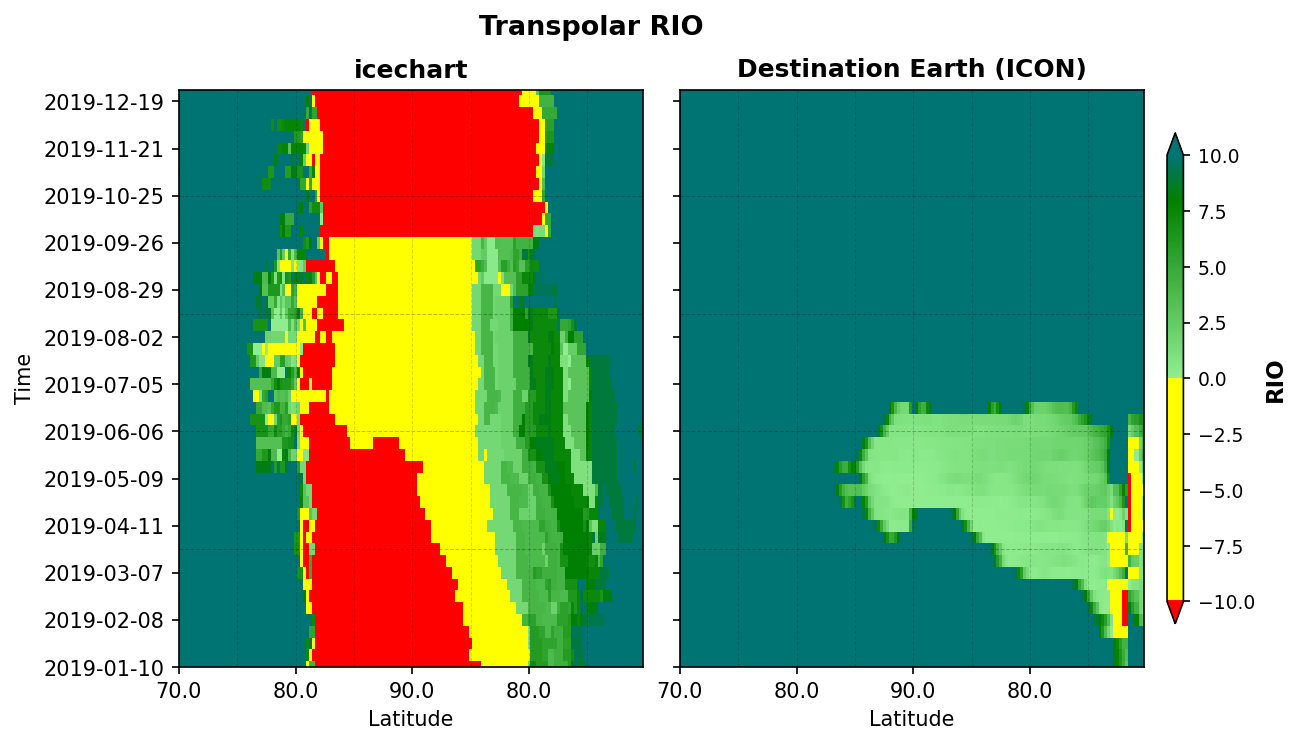

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

def plot_transpolar_two(
    rio_PC5_DE, transpolarrio_DE,
    cmap=riomapAGI2,
    vmin=-10, vmax=10,
    x_ticks_step=20, y_ticks_step=10,
    hline_step=10, vline_step=20,
    figsize=(10, 5),
    savepath=None
):
    # Expect (50, 160)
    assert rio_PC5_DE.shape == (50, 160) and transpolarrio_DE.shape == (50, 160), "Arrays must be (50,160)"

    y = np.arange(50)     # 0..49
    x = np.arange(160)    # 0..159
    X, Y = np.meshgrid(x, y)

    fig = plt.figure(figsize=figsize, dpi=150)
    gs = fig.add_gridspec(1, 2, wspace=0.08)
    axA = fig.add_subplot(gs[0, 0])
    axB = fig.add_subplot(gs[0, 1])

    norm = Normalize(vmin=vmin, vmax=vmax)
    pcmA = axA.pcolormesh(X, Y, rio_PC5_DE, cmap=cmap, norm=norm, shading="nearest", rasterized=True, zorder=2)
    pcmB = axB.pcolormesh(X, Y, transpolarrio_DE, cmap=cmap, norm=norm, shading="nearest", rasterized=True, zorder=2)

    # Axes styling + guides
    for ax, subtitle in ((axA, "icechart"), (axB, "Destination Earth (ICON)")):
        ax.set_xticks(range(len(lonindexpolar[:-1]))[::40], latitude_all[::40])
        ax.set_yticks(range(50)[::4],timestamps_date[::4])
        ax.set_xlim(0, 159)
        ax.set_ylim(0, 49)
        ax.set_xlabel("Latitude")
        ax.set_title(subtitle, fontsize=12, weight="bold")

        for yv in range(0, 50, hline_step):
            ax.axhline(y=yv, color="black", linewidth=0.5, linestyle="--", alpha=0.25, zorder=3)
        for xv in range(0, 160, vline_step):
            ax.axvline(x=xv, color="black", linewidth=0.5, linestyle="--", alpha=0.15, zorder=3)

    axA.set_ylabel("Time")
    axB.set_yticklabels([])

    # Shared colorbar
    cbar = fig.colorbar(pcmB, ax=[axA, axB], shrink=0.85, pad=0.02, aspect=30, extend="both")
    cbar.set_label("RIO", fontsize=11, weight="bold")
    cbar.ax.tick_params(labelsize=9)

    # Main title
    fig.suptitle("Transpolar RIO", x=0.4,y=0.98, fontsize=13, weight="bold")

    if savepath:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()

plot_transpolar_two(rio_profile_PC5_trim, transpolarrio_DE, savepath="/work/data/zhang/NOCOSRIOgit/usecases/RIO/plots/transpolar_rio_two.png")


In [63]:
transpolarrio_DE.shape

(50, 160)